In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

print("Libraries loaded!")

ModuleNotFoundError: No module named 'sklearn'

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

print("Libraries loaded!")

Libraries loaded!


In [3]:
df = pd.read_csv('data/master_dataset.csv')

# keep only rows with price
df = df.dropna(subset=['price'])

# encode platform (Etsy/Amazon) as numbers — ML needs numbers not text
le = LabelEncoder()
df['platform_encoded'] = le.fit_transform(df['source'])

# extract title length as a feature
df['title_length'] = df['title'].str.len()

# extract key keywords as features
df['has_embroidered'] = df['title'].str.lower().str.contains('embroidered').astype(int)
df['has_kani'] = df['title'].str.lower().str.contains('kani').astype(int)
df['has_pashmina'] = df['title'].str.lower().str.contains('pashmina').astype(int)
df['has_luxury'] = df['title'].str.lower().str.contains('luxury').astype(int)
df['has_handmade'] = df['title'].str.lower().str.contains('handmade').astype(int)
df['has_authentic'] = df['title'].str.lower().str.contains('authentic').astype(int)

print(df[['title', 'price', 'platform_encoded', 'has_embroidered', 'has_kani', 'has_luxury']].head())
print(f"\nTotal rows: {len(df)}")

                                               title    price  \
0  Pashmina Shawl with Intricate Bird and Floral ...   6761.0   
1  Authentic kashmiri pashmina handmade tilla sha...  43825.0   
2  Hand Embroidered on pure Pashmina Shawl: Kashm...  16159.0   
3  Multi Embroidered Pashmina Shawl | Floral Aari...   6160.0   
4  Luxury Embroidered Pashmina Shawl, Ivory Kashm...   7061.0   

   platform_encoded  has_embroidered  has_kani  has_luxury  
0                 1                0         0           0  
1                 1                0         0           0  
2                 1                1         0           0  
3                 1                1         0           0  
4                 1                1         0           1  

Total rows: 173


In [4]:
# define features and target
features = ['platform_encoded', 'title_length', 'has_embroidered', 
            'has_kani', 'has_pashmina', 'has_luxury', 'has_handmade', 'has_authentic']

X = df[features]
y = df['price']

# split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

# train linear regression
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# test it
y_pred = model_lr.predict(X_test)

# evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nLinear Regression Results:")
print(f"Mean Absolute Error: ₹{mae:.0f}")
print(f"R2 Score: {r2:.3f}")

Training rows: 138
Testing rows: 35

Linear Regression Results:
Mean Absolute Error: ₹14596
R2 Score: -0.027


In [5]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Results:")
print(f"Mean Absolute Error: ₹{mae_rf:.0f}")
print(f"R2 Score: {r2_rf:.3f}")

# compare both models
print(f"\n=== MODEL COMPARISON ===")
print(f"Linear Regression — MAE: ₹{mae:.0f}, R2: {r2:.3f}")
print(f"Random Forest     — MAE: ₹{mae_rf:.0f}, R2: {r2_rf:.3f}")

Random Forest Results:
Mean Absolute Error: ₹18938
R2 Score: -0.322

=== MODEL COMPARISON ===
Linear Regression — MAE: ₹14596, R2: -0.027
Random Forest     — MAE: ₹18938, R2: -0.322


In [6]:
df_etsy = df[df['source'] == 'Etsy'].copy()
df_etsy = df_etsy.dropna(subset=['price', 'rating'])

X_etsy = df_etsy[features]
y_etsy = df_etsy['price']

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(X_etsy, y_etsy, test_size=0.2, random_state=42)

model_rf2 = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf2.fit(X_train_e, y_train_e)

y_pred_e = model_rf2.predict(X_test_e)

print(f"Random Forest (Etsy only):")
print(f"MAE: ₹{mean_absolute_error(y_test_e, y_pred_e):.0f}")
print(f"R2: {r2_score(y_test_e, y_pred_e):.3f}")

Random Forest (Etsy only):
MAE: ₹20066
R2: -0.080


In [7]:
df_etsy2 = pd.read_csv('data/etsy_clean.csv')
df_etsy2 = df_etsy2.dropna(subset=['sale_price', 'rating'])

# better features
df_etsy2['title_length'] = df_etsy2['title'].str.len()
df_etsy2['has_embroidered'] = df_etsy2['title'].str.lower().str.contains('embroidered').astype(int)
df_etsy2['has_kani'] = df_etsy2['title'].str.lower().str.contains('kani').astype(int)
df_etsy2['has_luxury'] = df_etsy2['title'].str.lower().str.contains('luxury').astype(int)
df_etsy2['has_handmade'] = df_etsy2['title'].str.lower().str.contains('handmade').astype(int)
df_etsy2['has_authentic'] = df_etsy2['title'].str.lower().str.contains('authentic').astype(int)
df_etsy2['discount_pct'] = df_etsy2['discount'].str.replace('(','').str.replace('% off)','').str.strip()
df_etsy2['discount_pct'] = pd.to_numeric(df_etsy2['discount_pct'], errors='coerce').fillna(0)

features2 = ['rating', 'title_length', 'has_embroidered', 'has_kani', 
             'has_luxury', 'has_handmade', 'has_authentic', 'discount_pct']

X2 = df_etsy2[features2]
y2 = df_etsy2['sale_price']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

model_rf3 = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf3.fit(X_train2, y_train2)

y_pred3 = model_rf3.predict(X_test2)

print(f"Random Forest (Etsy + better features):")
print(f"MAE: ₹{mean_absolute_error(y_test2, y_pred3):.0f}")
print(f"R2: {r2_score(y_test2, y_pred3):.3f}")

Random Forest (Etsy + better features):
MAE: ₹17364
R2: 0.088


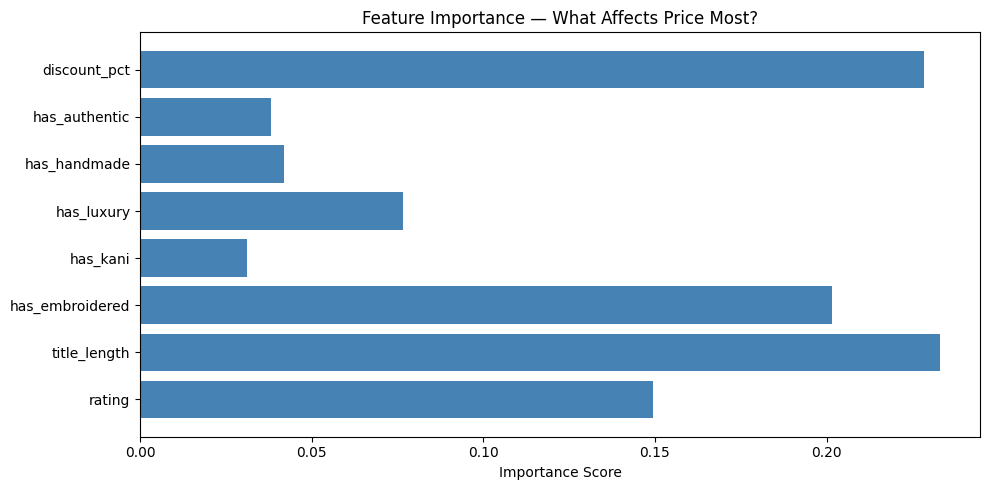

In [8]:
importances = model_rf3.feature_importances_
feat_names = features2

plt.figure(figsize=(10, 5))
plt.barh(feat_names, importances, color='steelblue')
plt.title('Feature Importance — What Affects Price Most?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [9]:
def predict_price(rating, title, discount_pct):
    title_length = len(title)
    has_embroidered = 1 if 'embroidered' in title.lower() else 0
    has_kani = 1 if 'kani' in title.lower() else 0
    has_luxury = 1 if 'luxury' in title.lower() else 0
    has_handmade = 1 if 'handmade' in title.lower() else 0
    has_authentic = 1 if 'authentic' in title.lower() else 0

    features_input = [[rating, title_length, has_embroidered, has_kani,
                       has_luxury, has_handmade, has_authentic, discount_pct]]
    
    predicted = model_rf3.predict(features_input)[0]
    return round(predicted, 0)

# test it
title1 = "Authentic Hand Embroidered Kani Pashmina Shawl, Luxury Kashmiri Wrap"
price1 = predict_price(rating=4.8, title=title1, discount_pct=20)
print(f"Predicted price for: {title1}")
print(f"₹{price1}")

title2 = "Soft Pashmina Shawl Wrap"
price2 = predict_price(rating=4.2, title=title2, discount_pct=50)
print(f"\nPredicted price for: {title2}")
print(f"₹{price2}")

Predicted price for: Authentic Hand Embroidered Kani Pashmina Shawl, Luxury Kashmiri Wrap
₹25965.0

Predicted price for: Soft Pashmina Shawl Wrap
₹6756.0


/home/syedtaha/shawl-business-intelligence/shawl-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/home/syedtaha/shawl-business-intelligence/shawl-env/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
